In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, MiniBatchKMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    adjusted_rand_score, normalized_mutual_info_score,
    homogeneity_score, completeness_score, v_measure_score
)
from sklearn.neighbors import NearestNeighbors

# Configuration
np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)


✓ All dependencies loaded successfully


In [ ]:
# Load cleaned dataset
df = pd.read_pickle('df_cleaned.pkl')

print(f"Dataset shape: {df.shape}")
print(f"\nAssuming first row of column info:")
print(df.head(3))

# Separate features and labels
if 'Label' in df.columns:
    X = df.drop('Label', axis=1)
    y = df['Label']
    print(f"\nLabel column found")
    print(f"Label distribution:")
    print(y.value_counts())
else:
    X = df
    y = None
    print("\nNo Label column found")

print(f"\nFeature matrix shape: {X.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

DATA LOADING
Dataset shape: (610794, 23)

Assuming first row of column info:
   Destination Port  Flow Duration  Fwd Packet Length Min  \
0                80          38308                      6   
1               389            479                      0   
2                88           1095                      0   

   Bwd Packet Length Max  Bwd Packet Length Min  Flow Packets/s  \
0                      6                      6       52.208416   
1                    163                      0    33402.922760   
2                   1575                      0    14611.872150   

   Flow IAT Mean  Flow IAT Std  Flow IAT Min  Fwd IAT Mean  Bwd IAT Total  \
0   38308.000000      0.000000         38308      0.000000              0   
1      31.933333     25.510409             0     47.900000            401   
2      73.000000    204.960972             1    121.666667            995   

   Bwd IAT Mean  Bwd IAT Std  Bwd IAT Max  Bwd IAT Min  Bwd Packets/s  \
0          0.00     0.00000

In [ ]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = X_scaled.astype('float32')

print(f"Scaled data shape: {X_scaled.shape}")
print(f"Data type: {X_scaled.dtype}")
print(f"Mean (should be ≈ 0): {X_scaled.mean():.6f}")
print(f"Std (should be ≈ 1): {X_scaled.std():.6f}")
print(f"Memory usage: {X_scaled.nbytes / 1024 / 1024:.2f} MB")


FEATURE STANDARDIZATION
Scaled data shape: (610794, 22)
Data type: float32
Mean (should be ≈ 0): 0.000000
Std (should be ≈ 1): 1.000000
Memory usage: 51.26 MB


In [ ]:
# Pre-compute PCA once for both 2D and 3D visualizations
pca_2d = PCA(n_components=min(2, X_scaled.shape[1], X_scaled.shape[0]))
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_3d = PCA(n_components=min(3, X_scaled.shape[1], X_scaled.shape[0]))
X_pca_3d = pca_3d.fit_transform(X_scaled)

# Ensure 3D array has 3 components
if X_pca_3d.shape[1] < 3:
    X_pca_3d = np.hstack([X_pca_3d, np.zeros((X_pca_3d.shape[0], 3 - X_pca_3d.shape[1]))])

print(f"2D PCA - Variance explained: {pca_2d.explained_variance_ratio_}")
print(f"2D PCA - Cumulative variance: {pca_2d.explained_variance_ratio_.sum():.2%}")
print(f"\n3D PCA - Variance explained: {pca_3d.explained_variance_ratio_}")
print(f"3D PCA - Cumulative variance: {pca_3d.explained_variance_ratio_.sum():.2%}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(1, len(pca_2d.explained_variance_ratio_) + 1),
            pca_2d.explained_variance_ratio_, alpha=0.7, color='steelblue')
axes[0].plot(range(1, len(pca_2d.explained_variance_ratio_) + 1),
             np.cumsum(pca_2d.explained_variance_ratio_), 'ro-', linewidth=2, label='Cumulative')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained Ratio')
axes[0].set_title('PCA: 2D Scree Plot')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(range(1, len(pca_3d.explained_variance_ratio_) + 1),
            pca_3d.explained_variance_ratio_, alpha=0.7, color='coral')
axes[1].plot(range(1, len(pca_3d.explained_variance_ratio_) + 1),
             np.cumsum(pca_3d.explained_variance_ratio_), 'ro-', linewidth=2, label='Cumulative')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Variance Explained Ratio')
axes[1].set_title('PCA: 3D Scree Plot')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_analysis.png', dpi=100, bbox_inches='tight')
plt.close()
print("\n✓ PCA visualization saved")


PCA ANALYSIS
2D PCA - Variance explained: [0.30684495 0.12795585]
2D PCA - Cumulative variance: 43.48%

3D PCA - Variance explained: [0.30684495 0.12795585 0.09646847]
3D PCA - Cumulative variance: 53.13%

✓ PCA visualization saved


In [ ]:
k_values = range(2, min(8, X_scaled.shape[0] + 1))
kmeans_results = {}
kmeans_models = {}

# ADAPTIVE SAMPLING: reduce computation for large datasets
n_samples = X_scaled.shape[0]
if n_samples <= 20000:
    sample_fit_size = n_samples
    sample_eval_size = n_samples
    X_sample = X_scaled
    X_eval = X_scaled
else:
    # For large datasets, use separate fit and eval sets
    sample_eval_size = min(20000, n_samples // 2)
    sample_fit_size = min(50000, n_samples - sample_eval_size)
    sample_fit_indices = np.random.choice(n_samples, size=sample_fit_size, replace=False)
    remaining_indices = np.setdiff1d(np.arange(n_samples), sample_fit_indices)
    sample_eval_indices = np.random.choice(remaining_indices, size=sample_eval_size, replace=False)
    X_sample = X_scaled[sample_fit_indices]
    X_eval = X_scaled[sample_eval_indices]

print(f"\nK-Means Analysis (fit: {sample_fit_size} samples, eval: {sample_eval_size} samples)")
print(f"{'k':<4} {'Inertia':<14} {'Silhouette':<12} {'Davies-Bouldin':<14}")
print("-" * 50)

for k in k_values:
    # MiniBatchKMeans for speed on large datasets
    kmeans = MiniBatchKMeans(
        n_clusters=k,
        batch_size=2048,
        random_state=42,
        n_init=10,
        max_iter=100
    )
    kmeans.fit(X_sample)
    
    # Predict on full dataset for later analysis
    kmeans_labels = kmeans.predict(X_scaled)
    kmeans_models[k] = (kmeans, kmeans_labels)
    
    # Metrics on evaluation set
    eval_labels = kmeans.predict(X_eval)
    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_eval, eval_labels, n_jobs=-1)
    davies_bouldin = davies_bouldin_score(X_eval, eval_labels)
    
    kmeans_results[k] = {
        'inertia': inertia,
        'silhouette': silhouette,
        'davies_bouldin': davies_bouldin
    }
    
    print(f"{k:<4} {inertia:<14.2f} {silhouette:<12.4f} {davies_bouldin:<14.4f}")

optimal_k = max(kmeans_results, key=lambda k: kmeans_results[k]['silhouette'])
print(f"\nOptimal k (by Silhouette): {optimal_k}")

# Get optimal labels
_, kmeans_optimal_labels = kmeans_models[optimal_k]


K-MEANS CLUSTERING ANALYSIS

K-Means Analysis (fit: 50000 samples, eval: 20000 samples)
k    Inertia        Silhouette   Davies-Bouldin
--------------------------------------------------
2    827402.94      0.4019       1.3486        
3    760894.56      0.3179       1.5929        
4    632125.25      0.4189       1.0268        
5    578949.25      0.4158       1.2048        
6    501215.81      0.4355       1.1734        
7    502044.41      0.3420       1.3631        

✓ Optimal k (by Silhouette): 6


In [ ]:
# Visualization: K-Means evaluation metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

k_list = list(k_values)
inertias = [kmeans_results[k]['inertia'] for k in k_list]
silhouettes = [kmeans_results[k]['silhouette'] for k in k_list]
db_indices = [kmeans_results[k]['davies_bouldin'] for k in k_list]

axes[0].plot(k_list, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia', fontsize=11)
axes[0].set_title('K-Means: Elbow Method', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_list, silhouettes, 'go-', linewidth=2, markersize=8)
axes[1].axvline(optimal_k, color='r', linestyle='--', label=f'Optimal k={optimal_k}')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('K-Means: Silhouette Score', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(k_list, db_indices, 'ro-', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[2].set_ylabel('Davies-Bouldin Index', fontsize=11)
axes[2].set_title('K-Means: Davies-Bouldin (Lower is Better)', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_evaluation.png', dpi=100, bbox_inches='tight')
plt.close(fig)
print("K-Means evaluation metrics saved")

✓ K-Means evaluation metrics saved


In [ ]:
linkage_criteria = ['ward', 'complete', 'average', 'single']
hc_results = {}
hc_models = {}

# ADAPTIVE SAMPLING: HC has O(n^2) complexity so use smaller sample
n_samples = X_scaled.shape[0]
hierarchical_sample_size = max(2, min(10000, n_samples))
hierarchical_eval_size = min(4000, max(2, hierarchical_sample_size // 4))
hc_sample_indices = np.random.choice(n_samples, size=hierarchical_sample_size, replace=False)
hc_eval_positions = np.random.choice(hierarchical_sample_size, size=hierarchical_eval_size, replace=False)
X_hc_sample = X_scaled[hc_sample_indices]
X_hc_eval = X_hc_sample[hc_eval_positions]

print(f"\nHierarchical Analysis (sample: {hierarchical_sample_size}, eval: {hierarchical_eval_size})")
print(f"{'Linkage':<12} {'Silhouette':<12} {'Davies-Bouldin':<14}")
print("-" * 40)

for linkage in linkage_criteria:
    hc = AgglomerativeClustering(n_clusters=optimal_k, linkage=linkage)
    hc_labels_sample = hc.fit_predict(X_hc_sample)
    
    # Assign full-data labels using nearest cluster centroid
    centroids = np.vstack([X_hc_sample[hc_labels_sample == label].mean(axis=0)
                           for label in range(optimal_k)])
    centroid_nn = NearestNeighbors(n_neighbors=1, n_jobs=-1).fit(centroids)
    hc_labels_full = centroid_nn.kneighbors(X_scaled, return_distance=False).reshape(-1)
    
    eval_labels = hc_labels_sample[hc_eval_positions]
    silhouette = silhouette_score(X_hc_eval, eval_labels, n_jobs=-1)
    davies_bouldin = davies_bouldin_score(X_hc_eval, eval_labels)
    
    hc_results[linkage] = {
        'silhouette': silhouette,
        'davies_bouldin': davies_bouldin,
        'labels': hc_labels_full
    }
    hc_models[linkage] = hc
    
    print(f"{linkage:<12} {silhouette:<12.4f} {davies_bouldin:<14.4f}")
    
    # Clean up temporary objects
    del centroid_nn, centroids

best_linkage = max(hc_results, key=lambda x: hc_results[x]['silhouette'])
print(f"\nBest linkage (by Silhouette): {best_linkage}")

# Get optimal labels
hc_optimal_labels = hc_results[best_linkage]['labels']


HIERARCHICAL CLUSTERING ANALYSIS

Hierarchical Analysis (sample: 10000, eval: 2500)
Linkage      Silhouette   Davies-Bouldin
----------------------------------------
ward         0.3491       0.9467        
complete     0.6837       0.3129        
average      0.7695       0.3152        
single       0.7696       0.1292        

✓ Best linkage (by Silhouette): single


In [ ]:
# Visualization: Hierarchical Clustering
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, linkage in enumerate(linkage_criteria):
    labels = hc_results[linkage]['labels']
    sil = hc_results[linkage]['silhouette']
    db = hc_results[linkage]['davies_bouldin']
    
    scatter = axes[idx].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                               c=labels, cmap='viridis', s=30, alpha=0.6, edgecolors='k', linewidth=0.3)
    axes[idx].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})', fontsize=10)
    axes[idx].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})', fontsize=10)
    axes[idx].set_title(f'HC: {linkage.upper()}\nSilhouette: {sil:.4f} | DB: {db:.4f}',
                       fontsize=11, fontweight='bold')
    plt.colorbar(scatter, ax=axes[idx], label='Cluster')

plt.tight_layout()
plt.savefig('hierarchical_clustering.png', dpi=100, bbox_inches='tight')
plt.close(fig)
print("Hierarchical clustering visualization saved")

✓ Hierarchical clustering visualization saved


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# K-distance graph logic
dbscan_sample_size = min(10000, X_scaled.shape[0])
dbscan_sample_indices = np.random.choice(X_scaled.shape[0], size=dbscan_sample_size, replace=False)
X_dbscan_sample = X_scaled[dbscan_sample_indices]

k = min(X_scaled.shape[1], 10)
neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(X_dbscan_sample)
distances, _ = neighbors.kneighbors(X_dbscan_sample)
distances = np.sort(distances[:, k-1], axis=0)

# eps calculation
dist_mean = distances.mean()
dist_std = distances.std()
start_eps = max(0.1, dist_mean - dist_std)
stop_eps = max(start_eps + 0.5, dist_mean + 2 * dist_std)

eps_values = np.linspace(start_eps, stop_eps, 5)
min_samples_values = [5, 10]

dbscan_results = {}
best_config = None
best_score = -1.0

print(f"\nDBSCAN Search (on {dbscan_sample_size} samples):")
print(f"{'eps':<6} {'min_samp':<10} {'clusters':<10} {'noise %':<10} {'Silhouette':<12}")
print("-" * 55)

for eps in eps_values:
    for min_samples in min_samples_values:
        try:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            labels = dbscan.fit_predict(X_dbscan_sample)
            
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = (labels == -1).sum()
            noise_ratio = n_noise / len(labels)
            
            if n_clusters >= 2 and n_clusters < len(X_dbscan_sample) * 0.1:
                mask = labels != -1
                if mask.any() and len(set(labels[mask])) > 1:
                    score = silhouette_score(X_dbscan_sample[mask], labels[mask])
                    if score > best_score:
                        best_score = score
                        best_config = (eps, min_samples)
                    print(f"{eps:<6.2f} {min_samples:<10} {n_clusters:<10} {noise_ratio:<10.1%} {score:<12.4f}")
                else:
                    print(f"{eps:<6.2f} {min_samples:<10} {n_clusters:<10} {noise_ratio:<10.1%} {'N/A':<12}")
            else:
                print(f"{eps:<6.2f} {min_samples:<10} {n_clusters:<10} {noise_ratio:<10.1%} {'Skip':<12}")
        except Exception:
            continue

# --- RAM-EFFICIENT FIX APPLIED HERE ---
if best_config:
    final_eps, final_min_samples = best_config
    print(f"\nBest config: eps={final_eps:.2f}, min_samples={final_min_samples}")
else:
    final_eps, final_min_samples = np.percentile(distances, 90), 10
    print(f"\nNo best config found. Using heuristic: eps={final_eps:.2f}")

# Fit on the sample to get the cluster "map"
dbscan_final = DBSCAN(eps=final_eps, min_samples=final_min_samples)
sample_labels = dbscan_final.fit_predict(X_dbscan_sample)

# Propagate labels to full dataset using NearestNeighbors (Low RAM)
mask = sample_labels != -1
if mask.any():
    # Use KNN to map every point in X_scaled to its nearest neighbor in the clustered sample
    knn = KNeighborsClassifier(n_neighbors=1, n_jobs=-1)
    knn.fit(X_dbscan_sample[mask], sample_labels[mask])
    dbscan_optimal_labels = knn.predict(X_scaled)
    
    # Points further than eps from any known cluster core are noise (-1)
    dists, _ = knn.kneighbors(X_scaled, n_neighbors=1)
    dbscan_optimal_labels[dists.flatten() > final_eps] = -1
else:
    dbscan_optimal_labels = np.full(X_scaled.shape[0], -1)

n_final_clusters = len(set(dbscan_optimal_labels)) - (1 if -1 in dbscan_optimal_labels else 0)
print(f"Final DBSCAN clusters: {n_final_clusters}")


DBSCAN CLUSTERING ANALYSIS

DBSCAN Search (on 10000 samples):
eps    min_samp   clusters   noise %    Silhouette  
-------------------------------------------------------
0.10   5          257        36.2%      0.3257      
0.10   10         106        49.6%      0.3388      
0.77   5          51         5.8%       0.2422      
0.77   10         29         8.3%       0.3994      
1.45   5          27         2.4%       -0.0353     
1.45   10         19         3.6%       0.1551      
2.12   5          19         1.3%       0.1958      
2.12   10         11         2.1%       0.2130      
2.80   5          12         0.9%       0.0932      
2.80   10         7          1.5%       0.0949      

✓ Best config: eps=0.77, min_samples=10
Final DBSCAN clusters: 29


In [ ]:
# Ensure variables exist to prevent NameError
# We map the final variables used in the previous step back to the comparison names
b_eps = best_config[0] if best_config else (final_eps if 'final_eps' in locals() else 0)
b_ms = best_config[1] if best_config else (final_min_samples if 'final_min_samples' in locals() else 0)

# Safely extract DBSCAN metrics
db_res = dbscan_results.get((b_eps, b_ms), {'n_clusters': 0, 'silhouette': np.nan, 'davies_bouldin': np.nan})

comparison_data = {
    'Algorithm': ['K-Means', 'Hierarchical', 'DBSCAN'],
    'Parameters': [
        f'k={optimal_k}',
        f'linkage={best_linkage}',
        f'eps={b_eps:.2f}, ms={b_ms}'
    ],
    'N_Clusters': [
        optimal_k,
        optimal_k,
        len(set(dbscan_optimal_labels)) - (1 if -1 in dbscan_optimal_labels else 0)
    ],
    'Silhouette': [
        kmeans_results[optimal_k]['silhouette'],
        hc_results[best_linkage]['silhouette'],
        db_res.get('silhouette', np.nan)
    ],
    'Davies-Bouldin': [
        kmeans_results[optimal_k]['davies_bouldin'],
        hc_results[best_linkage]['davies_bouldin'],
        db_res.get('davies_bouldin', np.nan)
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))


ALGORITHM COMPARISON
   Algorithm      Parameters  N_Clusters  Silhouette  Davies-Bouldin
     K-Means             k=6           6    0.435525        1.173388
Hierarchical  linkage=single           6    0.769568        0.129179
      DBSCAN eps=0.77, ms=10          29         NaN             NaN


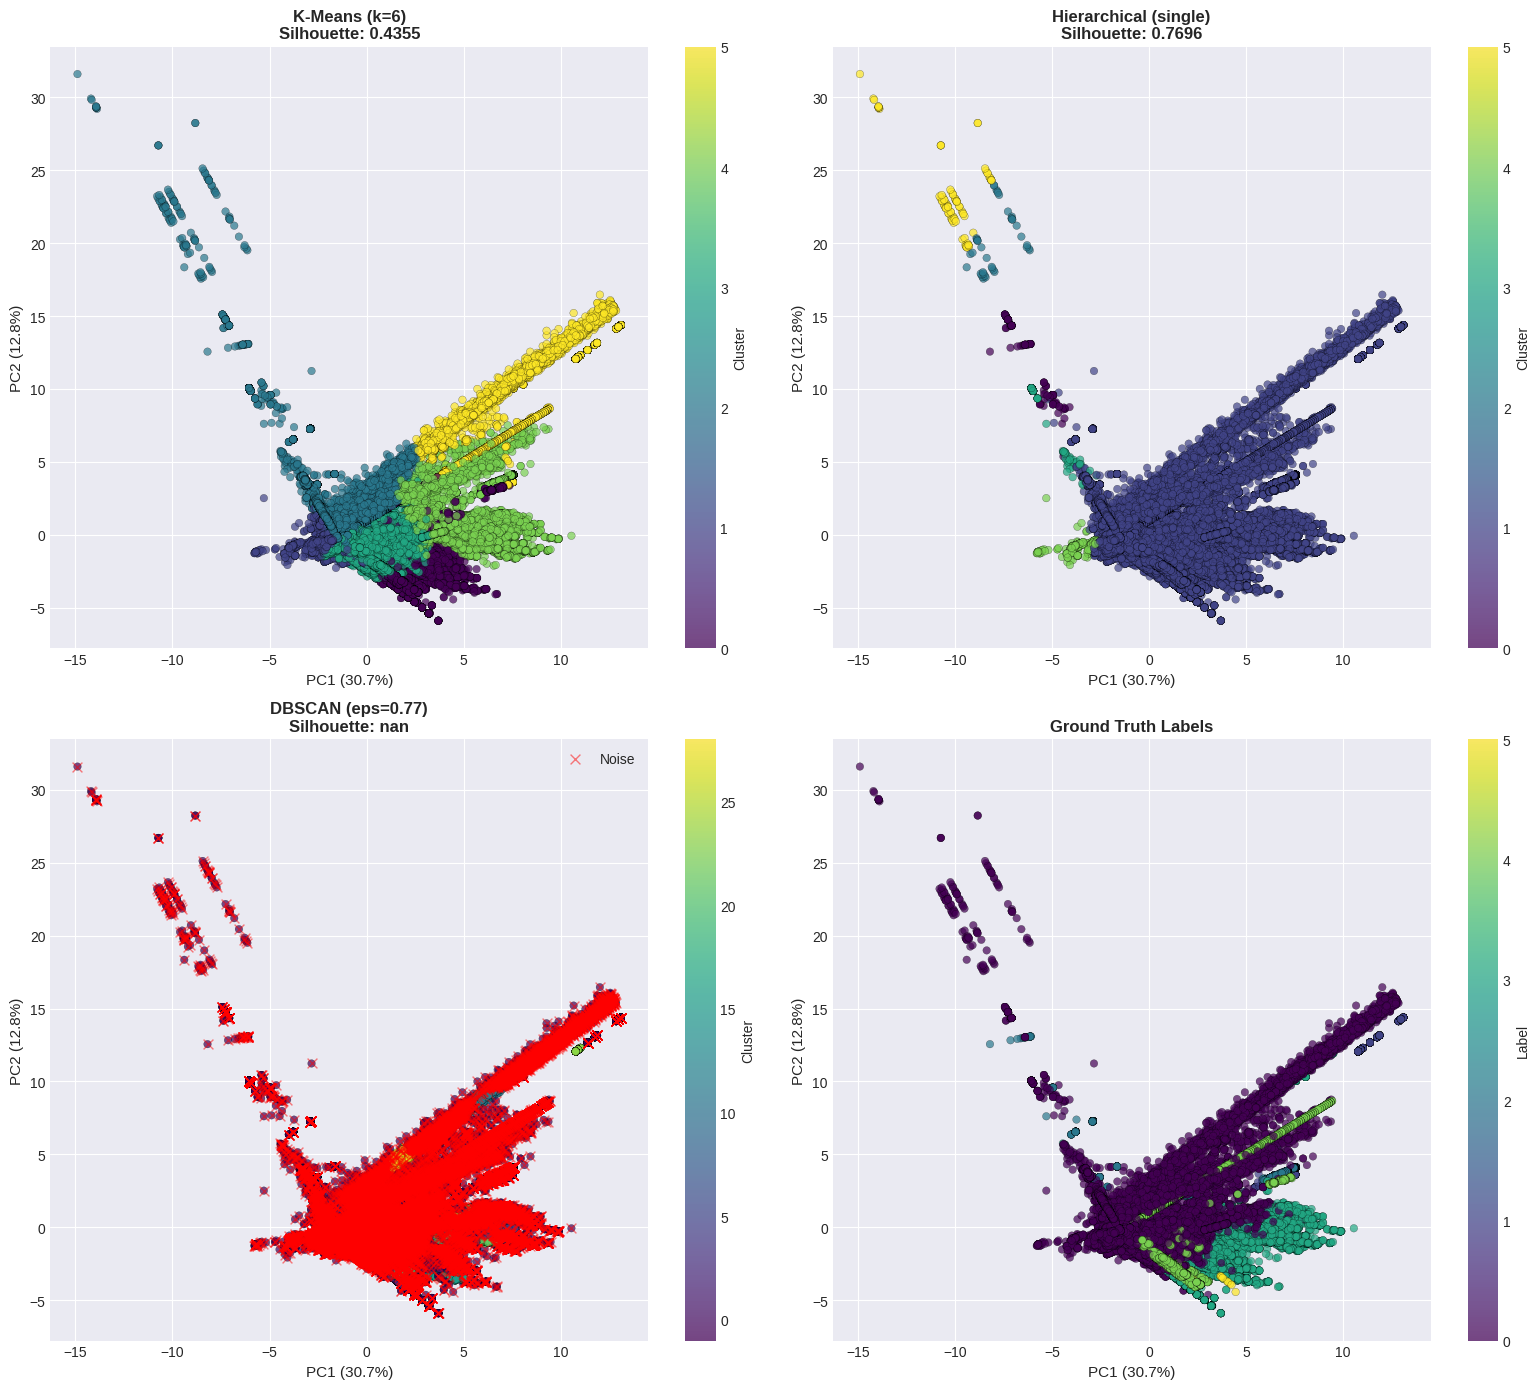


✓ Algorithm comparison visualization saved


In [ ]:
# Visualization: Algorithm comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

pca_var1 = pca_2d.explained_variance_ratio_[0]
pca_var2 = pca_2d.explained_variance_ratio_[1]

# Use the variables established in the previous step to avoid NameError
# If best_config doesn't exist, we fallback to final_eps from the RAM fix
b_eps = best_config[0] if 'best_config' in locals() and best_config else (final_eps if 'final_eps' in locals() else 0)

# K-Means
scatter1 = axes[0, 0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                             c=kmeans_optimal_labels, cmap='viridis', s=30, alpha=0.7, edgecolors='k', linewidth=0.2)
axes[0, 0].set_xlabel(f'PC1 ({pca_var1:.1%})', fontsize=11)
axes[0, 0].set_ylabel(f'PC2 ({pca_var2:.1%})', fontsize=11)
axes[0, 0].set_title(f'K-Means (k={optimal_k})\nSilhouette: {comparison_df.loc[0, "Silhouette"]:.4f}',
                    fontsize=12, fontweight='bold')
plt.colorbar(scatter1, ax=axes[0, 0], label='Cluster')

# Hierarchical
scatter2 = axes[0, 1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                             c=hc_optimal_labels, cmap='viridis', s=30, alpha=0.7, edgecolors='k', linewidth=0.2)
axes[0, 1].set_xlabel(f'PC1 ({pca_var1:.1%})', fontsize=11)
axes[0, 1].set_ylabel(f'PC2 ({pca_var2:.1%})', fontsize=11)
axes[0, 1].set_title(f'Hierarchical ({best_linkage})\nSilhouette: {comparison_df.loc[1, "Silhouette"]:.4f}',
                    fontsize=12, fontweight='bold')
plt.colorbar(scatter2, ax=axes[0, 1], label='Cluster')

# DBSCAN
# Plot regular clusters
scatter3 = axes[1, 0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                             c=dbscan_optimal_labels, cmap='viridis', s=30, alpha=0.7, edgecolors='k', linewidth=0.2)

# Overlay noise points in red
mask_noise = dbscan_optimal_labels == -1
if mask_noise.any():
    axes[1, 0].scatter(X_pca_2d[mask_noise, 0], X_pca_2d[mask_noise, 1],
                      c='red', marker='x', s=50, linewidth=1, label='Noise', alpha=0.5)

axes[1, 0].set_xlabel(f'PC1 ({pca_var1:.1%})', fontsize=11)
axes[1, 0].set_ylabel(f'PC2 ({pca_var2:.1%})', fontsize=11)
axes[1, 0].set_title(f'DBSCAN (eps={b_eps:.2f})\nSilhouette: {comparison_df.loc[2, "Silhouette"]:.4f}',
                    fontsize=12, fontweight='bold')
plt.colorbar(scatter3, ax=axes[1, 0], label='Cluster')
if mask_noise.any():
    axes[1, 0].legend()

# Ground truth
if y is not None:
    y_encoded = pd.factorize(y)[0]
    scatter4 = axes[1, 1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                                 c=y_encoded, cmap='viridis', s=30, alpha=0.7, edgecolors='k', linewidth=0.2)
    axes[1, 1].set_xlabel(f'PC1 ({pca_var1:.1%})', fontsize=11)
    axes[1, 1].set_ylabel(f'PC2 ({pca_var2:.1%})', fontsize=11)
    axes[1, 1].set_title('Ground Truth Labels', fontsize=12, fontweight='bold')
    plt.colorbar(scatter4, ax=axes[1, 1], label='Label')
else:
    axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('algorithms_comparison.png', dpi=100, bbox_inches='tight')
plt.show() # Displaying the plot as well
print("\nAlgorithm comparison visualization saved")

In [ ]:
if y is not None:
    external_metrics = {
        'Algorithm': ['K-Means', 'Hierarchical', 'DBSCAN'],
        'ARI': [],
        'NMI': [],
        'V-Measure': []
    }
    
    # K-Means
    external_metrics['ARI'].append(adjusted_rand_score(y, kmeans_optimal_labels))
    external_metrics['NMI'].append(normalized_mutual_info_score(y, kmeans_optimal_labels))
    external_metrics['V-Measure'].append(v_measure_score(y, kmeans_optimal_labels))
    
    # Hierarchical
    external_metrics['ARI'].append(adjusted_rand_score(y, hc_optimal_labels))
    external_metrics['NMI'].append(normalized_mutual_info_score(y, hc_optimal_labels))
    external_metrics['V-Measure'].append(v_measure_score(y, hc_optimal_labels))
    
    # DBSCAN (exclude noise)
    mask = dbscan_optimal_labels != -1
    if mask.sum() > 0:
        external_metrics['ARI'].append(adjusted_rand_score(y[mask], dbscan_optimal_labels[mask]))
        external_metrics['NMI'].append(normalized_mutual_info_score(y[mask], dbscan_optimal_labels[mask]))
        external_metrics['V-Measure'].append(v_measure_score(y[mask], dbscan_optimal_labels[mask]))
    else:
        external_metrics['ARI'].append(np.nan)
        external_metrics['NMI'].append(np.nan)
        external_metrics['V-Measure'].append(np.nan)
    
    external_df = pd.DataFrame(external_metrics)
    print(external_df.to_string(index=False))
    
    # Contingency tables
    print("\nK-Means Contingency Table:")
    print(pd.crosstab(y, kmeans_optimal_labels, margins=True))
    
    print("\nHierarchical Clustering Contingency Table:")
    print(pd.crosstab(y, hc_optimal_labels, margins=True))
    
    print("\nDBSCAN Contingency Table (excluding noise):")
    if mask.sum() > 0:
        print(pd.crosstab(y[mask], dbscan_optimal_labels[mask], margins=True))
        print(f"\nNoise points: {(~mask).sum()} / {len(dbscan_optimal_labels)}")
else:
    print("No ground truth labels available")


COMPARISON WITH GROUND TRUTH LABELS
   Algorithm       ARI      NMI  V-Measure
     K-Means  0.297757 0.361749   0.361749
Hierarchical -0.001500 0.001793   0.001793
      DBSCAN  0.473954 0.444128   0.444128

K-Means Contingency Table:
col_0                  0      1       2       3      4     5     All
Label                                                               
BENIGN               332  73657  235729   93631   8040  5646  417035
DoS GoldenEye       2470      0     921    6051      6   838   10286
DoS Hulk           99871    222   16866   10798  45059    33  172849
DoS Slowhttptest       0      0    1009    3096   1123     0    5228
DoS slowloris        156      4     286    2020   1850  1069    5385
Heartbleed            11      0       0       0      0     0      11
All               102840  73883  254811  115596  56078  7586  610794

Hierarchical Clustering Contingency Table:
col_0               0       1   2    3    4   5     All
Label                                     

In [ ]:
# Pull values directly from comparison_df to ensure consistency and avoid NameErrors
best_sil_algo = comparison_df.loc[comparison_df['Silhouette'].idxmax(), 'Algorithm']
best_sil_val = comparison_df['Silhouette'].max()

best_db_algo = comparison_df.loc[comparison_df['Davies-Bouldin'].idxmin(), 'Algorithm']
best_db_val = comparison_df['Davies-Bouldin'].min()

# Safely get DBSCAN stats from the comparison_df row
dbscan_stats = comparison_df[comparison_df['Algorithm'] == 'DBSCAN'].iloc[0]
n_noise = (dbscan_optimal_labels == -1).sum()

print(f"""
 DATA CHARACTERISTICS:
  - Samples: {X_scaled.shape[0]}, Features: {X_scaled.shape[1]}
  - PCA PC1 Variance: {pca_2d.explained_variance_ratio_[0]:.2%}
  - PCA PC2 Variance: {pca_2d.explained_variance_ratio_[1]:.2%}
  - Total (PC1+PC2): {pca_2d.explained_variance_ratio_.sum():.2%}

 K-MEANS RESULTS (Optimal k={optimal_k}):
  - Silhouette: {kmeans_results[optimal_k]['silhouette']:.4f}
  - Davies-Bouldin: {kmeans_results[optimal_k]['davies_bouldin']:.4f}

 HIERARCHICAL RESULTS (Linkage: {best_linkage}):
  - Silhouette: {hc_results[best_linkage]['silhouette']:.4f}
  - Davies-Bouldin: {hc_results[best_linkage]['davies_bouldin']:.4f}

 DBSCAN RESULTS ({dbscan_stats['Parameters']}):
  - Silhouette: {dbscan_stats['Silhouette']:.4f}
  - Davies-Bouldin: {dbscan_stats['Davies-Bouldin']:.4f}
  - Final Noise Points: {n_noise}

 BEST PERFORMER (Internal Metrics):
  - Silhouette: {best_sil_algo} ({best_sil_val:.4f})
  - Davies-Bouldin: {best_db_algo} ({best_db_val:.4f})
""")


SUMMARY & KEY FINDINGS

✓ DATA CHARACTERISTICS:
  - Samples: 610794, Features: 22
  - PCA PC1 Variance: 30.68%
  - PCA PC2 Variance: 12.80%
  - Total (PC1+PC2): 43.48%

✓ K-MEANS RESULTS (Optimal k=6):
  - Silhouette: 0.4355
  - Davies-Bouldin: 1.1734

✓ HIERARCHICAL RESULTS (Linkage: single):
  - Silhouette: 0.7696
  - Davies-Bouldin: 0.1292

✓ DBSCAN RESULTS (eps=0.77, ms=10):
  - Silhouette: nan
  - Davies-Bouldin: nan
  - Final Noise Points: 47158

✓ BEST PERFORMER (Internal Metrics):
  - Silhouette: Hierarchical (0.7696)
  - Davies-Bouldin: Hierarchical (0.1292)

